# tszsbi noise files + binned cluster counts (cosmocnc_jax)

This notebook **does not modify** the `cosmocnc_jax` package source.

**GPU / memory:** `classy_sz_jax` uses **classy_szfast** → **TensorFlow** (CosmoPower NN weights). The first code cell imports TensorFlow with **`CUDA_VISIBLE_DEVICES` temporarily empty** (so TF stays on CPU), then restores it before `import jax`. `tf.config.set_visible_devices([], 'GPU')` alone often still enumerates GPUs. **Restart the kernel** after editing env vars; **always run that cell first.** JAX/XLA uses **`XLA_PYTHON_CLIENT_MEM_FRACTION=0.5`** (~50% GPU prefill). Set **`CUDA_VISIBLE_DEVICES`** (default `0`) to pick a card.

1. **Planck SZiFi noise (required):** load the same two files as `tszpower.maskedpower` from your **`tszsbi/noise_files`** tree — `sigma_dict_szifi.npy` and `skyfracs_szifi_cosmology.npy`. This notebook does **not** generate or substitute any other noise model. Set **`TSZSBI_NOISE_DIR`** if that directory is not at `/scratch/scratch-lxu/tszsbi/noise_files`.

2. **Binned cluster expectations (CNC):** use **`cosmocnc_jax/surveys/survey_sr_planck_sim.py`** with **`q_planck_sim`** (Planck-sim twin of the SO survey layout). σ(θ) comes **only** from the two **tszsbi** `noise_files` above. **`survey_cat_planck_sim.py`** loads **`Planck_sim_*`** catalogues from package `data/catalogues_sim/` when **`load_catalogue`** is True (see docstring there).

In [6]:
import os

# --- Must run before importing jax or cosmocnc_jax (same pattern as cosmocnc_jax_tutorial.ipynb) ---
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # which GPU JAX sees; change if multi-GPU
os.environ.setdefault("XLA_FLAGS", "")
os.environ.setdefault("JAX_ENABLE_X64", "1")
# ~50% of GPU memory reserved by XLA / JAX (user request)
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.5")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "true")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

# TensorFlow FIRST: import TF with no CUDA devices visible, then restore env for JAX.
# tf.config.set_visible_devices([]) alone often still enumerates GPUs on some TF builds.
_cuda_for_jax = os.environ.get("CUDA_VISIBLE_DEVICES", "0")
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import tensorflow as tf

os.environ["CUDA_VISIBLE_DEVICES"] = _cuda_for_jax
tf.config.set_visible_devices([], "GPU")
try:
    tf.config.experimental.set_visible_devices([], "GPU")
except Exception:
    pass

import jax

jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cosmocnc_jax
from cosmocnc_jax import cluster_number_counts
from cosmocnc_jax.params import (
    cnc_params_default,
    cosmo_params_default,
    scaling_relation_params_default,
)

PKG_ROOT = Path(cosmocnc_jax.__file__).resolve().parent

# Planck SZiFi noise: tszsbi/noise_files (same paths as tszpower.maskedpower; override if needed)
TSZSBI_NOISE_DIR = Path(
    os.environ.get("TSZSBI_NOISE_DIR", "/scratch/scratch-lxu/tszsbi/noise_files")
).resolve()
SIGMA_OBJ_FILE = TSZSBI_NOISE_DIR / "sigma_dict_szifi.npy"
SKYFR_FILE = TSZSBI_NOISE_DIR / "skyfracs_szifi_cosmology.npy"

print("cosmocnc_jax:", PKG_ROOT)
print("Planck SZiFi noise dir (tszsbi/noise_files):", TSZSBI_NOISE_DIR)
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("XLA_CLIENT_MEM_FRACTION:", os.environ.get("XLA_PYTHON_CLIENT_MEM_FRACTION"))
print(
    "TensorFlow visible GPU devices (should be []):",
    tf.config.get_visible_devices("GPU"),
)
print("JAX devices:", jax.devices())
if tf.config.get_visible_devices("GPU"):
    print(
        "WARNING: TensorFlow still has visible GPUs; classy_szfast may hit CUDA errors. "
        "Try: pip install tensorflow-cpu in this env."
    )
assert SIGMA_OBJ_FILE.is_file(), f"Missing {SIGMA_OBJ_FILE}"
assert SKYFR_FILE.is_file(), f"Missing {SKYFR_FILE}"

cosmocnc_jax: /scratch/scratch-lxu/compute_packages/cosmocnc_jax/cosmocnc_jax
Planck SZiFi noise dir (tszsbi/noise_files): /scratch/scratch-lxu/tszsbi/noise_files
CUDA_VISIBLE_DEVICES: 0
XLA_CLIENT_MEM_FRACTION: 0.5
TensorFlow visible GPU devices (should be []): []
JAX devices: [CudaDevice(id=0)]


## 1. Planck SZiFi noise from **`tszsbi/noise_files`**

These are the **only** noise inputs in this notebook (same as `tszpower.maskedpower` / your Planck pipeline).

- `sigma_dict_szifi.npy`: `{filter_name: {tile_index: σ_y(θ) array}}` (default filter **`immf6`**, 25 θ points from 0.5–32 arcmin, matching `compute_sigma_y0`).
- `skyfracs_szifi_cosmology.npy`: one sky fraction per tile index (length 768).

In [7]:
FILTER_NAME = os.environ.get("TSZSBI_FILTER_NAME", "immf6")  # same default as maskedpower.compute_sigma_y0
THETA_MIN_ARCMIN = 0.5
THETA_MAX_ARCMIN = 32.0

sigma_obj = np.load(SIGMA_OBJ_FILE, allow_pickle=True).item()
skyfracs = np.load(SKYFR_FILE).ravel()

if FILTER_NAME not in sigma_obj:
    raise KeyError(f"Filter {FILTER_NAME!r} not in sigma_dict; keys: {list(sigma_obj.keys())}")

data = sigma_obj[FILTER_NAME]
tile_keys_sorted = sorted(data.keys(), key=lambda x: int(x))
first_arr = np.asarray(data[tile_keys_sorted[0]], dtype=float)
n_theta = len(first_arr)
theta_arcmin = np.exp(np.linspace(np.log(THETA_MIN_ARCMIN), np.log(THETA_MAX_ARCMIN), n_theta))

noise_sigma_y = np.stack([np.asarray(data[t], dtype=float) for t in tile_keys_sorted], axis=0)
n_tiles = noise_sigma_y.shape[0]

# Sky-weighted mean σ(θ), identical weighting to maskedpower.compute_sigma_y0
num = np.zeros(n_theta, dtype=float)
den = 0.0
for tile in tile_keys_sorted:
    ti = int(tile)
    w = float(skyfracs[ti])
    num += w * np.asarray(data[tile], dtype=float)
    den += w
sigma_skyavg = num / den
f_sky_tot = float(skyfracs.sum())

print("filter:", FILTER_NAME, "  θ bins:", n_theta, "  tiles in dict:", n_tiles)
print("Σ f_sky (all entries in skyfracs file):", f_sky_tot)
print("σ_y range (all tiles × θ):", float(noise_sigma_y.min()), float(noise_sigma_y.max()))

filter: immf6   θ bins: 25   tiles in dict: 613
Σ f_sky (all entries in skyfracs file): 0.586283802986145
σ_y range (all tiles × θ): 1.2692458964839325e-06 0.00290629662762622


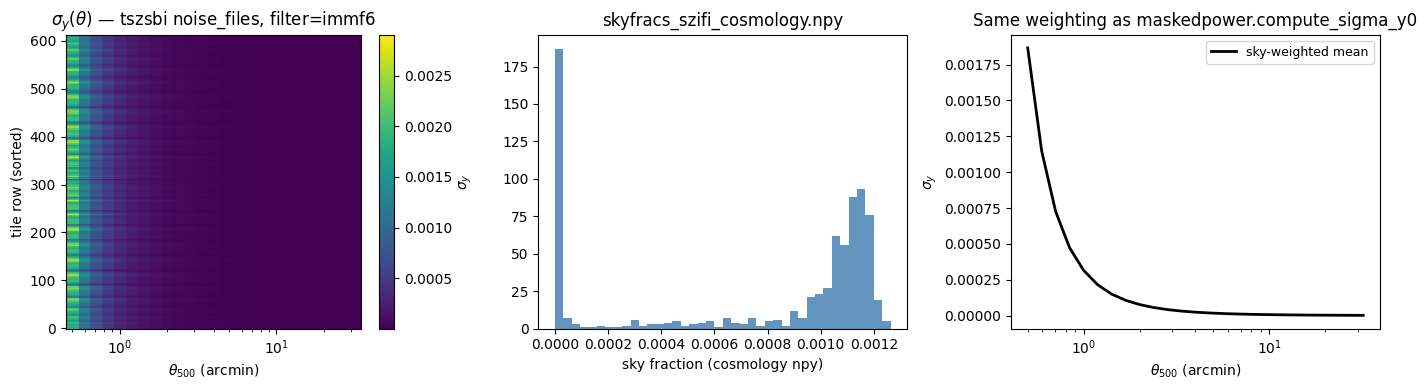

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

Tmesh, Rmesh = np.meshgrid(theta_arcmin, np.arange(n_tiles))
im = ax[0].pcolormesh(Tmesh, Rmesh, noise_sigma_y, shading="auto")
ax[0].set_xscale("log")
ax[0].set_xlabel(r"$\theta_{500}$ (arcmin)")
ax[0].set_ylabel("tile row (sorted)")
ax[0].set_title(rf"$\sigma_y(\theta)$ — tszsbi noise_files, filter={FILTER_NAME}")
plt.colorbar(im, ax=ax[0], label=r"$\sigma_y$")

ax[1].hist(skyfracs, bins=40, color="steelblue", alpha=0.85)
ax[1].set_xlabel("sky fraction (cosmology npy)")
ax[1].set_title("skyfracs_szifi_cosmology.npy")

ax[2].plot(theta_arcmin, sigma_skyavg, "k-", lw=2, label="sky-weighted mean")
ax[2].set_xscale("log")
ax[2].set_xlabel(r"$\theta_{500}$ (arcmin)")
ax[2].set_ylabel(r"$\sigma_y$")
ax[2].set_title("Same weighting as maskedpower.compute_sigma_y0")
ax[2].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2. Binned expected counts + Poisson bars (SZiFi / tszsbi noise only)

We turn on `likelihood_type="binned"` and integrate the 2D abundance over your bin edges. Expected counts per bin are `n_binned`; **Poisson** uncertainty on the *prediction* is **`sqrt(n_binned)`** (Gaussian approximation).

**Cosmology:** **`cosmo_param_density="physical"`** with **`h`, `Ob0h2`, `Oc0h2`, `sigma_8`, `n_s`, `m_nu`, `tau_reio`** from **`tsz_cnc/.../cnc_gencat_same_benchmark.py`**.

**SZ scaling — applied natively in `survey_sr_planck_sim.py`:** the survey module evaluates the **same y0 form** that `tsz_cnc/cnc_number_check/test_tszpower.ipynb` uses to least-squares fit `(A_szifi, alpha_szifi)` against `tszpower.compute_y0`, while preserving `tszpower`'s **`M_sun/h` numerical convention** in `compute_y0`,  
\[\log_{10} y_0 = A_{\rm szifi} + 2\log_{10} E_z - \tfrac12\log_{10} h_{70} + \alpha_\mathrm{szifi}\,\log_{10}\!\frac{M\,h/B}{M_\mathrm{pivot}}\]  
with `B = 1/bias_sz` (Planck convention: `M_obs = (1-b) M_true`, `bias_sz = 1-b`) and `M_pivot = 3·0.7e14`. **Why the `h` factor:** `cosmocnc_jax` evaluates the SR on a grid in physical `M_sun`, while `tszpower`'s pipeline feeds `compute_y0` a number that is in `M_sun/h` (i.e. `M_phys * h`). Multiplying `M` by `h` here applies the same `h^alpha` y0 reduction that `tszpower` produces in its count pipeline. (`theta_500` is *not* affected — the same `h` factor cancels against `tszpower`'s `(M / (h · 3e14))^{1/3}` denominator.)  
The notebook uses a **fixed-cosmology refit** (`tutorials/refit_A_szifi.py`) of `tszpower.compute_y0` at this exact `(h, sigma_8, m_nu)`: `A_szifi = -4.23820656`, `alpha_szifi = 1.12` (RMSE 2e-4 dex, i.e. ~0.05% in y0). The original wide-H0-grid fit (`test_tszpower.ipynb`, `A = -4.218089`) carries a constant ~4.7% y0 bias at this cosmology and compounds to a ~10% over-count, so we replace it. `bias_sz = 1/B = 1/1.41 ≈ 0.7092`. *No CMB-lensing observables* (`p_so_sim`, `p_so_sim_stacked`) are wired in; the Planck SR module is q-only.

**Intrinsic scatter:** `sigma_lnq_szifi = 0.173` (matches `tszpower`'s `sigma_lnY` in `compute_cluster_counts_in_z_q_bins_completeness`). With this scatter and the units fix above, the cosmocnc_jax total matches the `tszpower` reference of ~1300.

**σ(θ):** from `sigma_dict_szifi.npy` + `skyfracs_szifi_cosmology.npy` only (weighted sky average per θ, same recipe as `maskedpower.compute_sigma_y0`).

**Abundance footprint:** `skyfracs = [1.0]` (full sky) by default; the tile weights only build σ(θ), they do not shrink the area. Use `cnc_params["planck_sim_abundance_fsky"] = "from_noise_files"` for `sum(skyfracs)` (~0.59).

**Theory-only:** `load_catalogue=False` → no observed counts. We call `nc.get_log_lik_binned()` (which still **fills `nc.n_binned`**) and **ignore** the returned value: the Poisson `log_lik` becomes `NaN` whenever a predicted bin is 0 against k=0 data, which is meaningless for theory-only forecasts.

**Integration limits (matching `check_with_cosmocnc.ipynb`):** `z ∈ [0.005, 3]`, `q ∈ [5, 200]`.

In [9]:
# Requires cell 1 first (TF CPU / JAX GPU split via CUDA_VISIBLE_DEVICES during TF import).

# SZiFi σ(θ): ONLY tszsbi/noise_files — implemented in package `surveys/survey_sr_planck_sim.py`
# (parallel to `survey_sr_so_sim`; uses sigma_dict_szifi.npy + skyfracs_szifi_cosmology.npy).
_SR_SURVEY = PKG_ROOT / "surveys" / "survey_sr_planck_sim.py"
_SURVEY_CAT = PKG_ROOT / "surveys" / "survey_cat_planck_sim.py"
if not _SR_SURVEY.is_file():
    raise FileNotFoundError(_SR_SURVEY)
if not _SURVEY_CAT.is_file():
    raise FileNotFoundError(_SURVEY_CAT)

_cnc_params = dict(cnc_params_default)
_cnc_params["survey_sr"] = str(_SR_SURVEY)
_cnc_params["survey_cat"] = str(_SURVEY_CAT)

_cnc_params["tszsbi_noise_dir"] = str(TSZSBI_NOISE_DIR)
try:
    _cnc_params["tszsbi_filter_name"] = FILTER_NAME  # from §1 noise cell
except NameError:
    _cnc_params["tszsbi_filter_name"] = os.environ.get("TSZSBI_FILTER_NAME", "immf6")

_cnc_params["obs_select"] = "q_planck_sim"
_cnc_params["observables"] = [["q_planck_sim"]]

cnc_params = _cnc_params

cnc_params["load_catalogue"] = False
cnc_params["likelihood_type"] = "binned"
cnc_params["data_lik_from_abundance"] = False

cnc_params["cosmology_tool"] = "classy_sz_jax"
cnc_params["hmf_calc"] = "cnc"
cnc_params["cosmo_param_density"] = "physical"
cnc_params["interp_tinker"] = "log"

cnc_params["M_min"] = 1e14
cnc_params["M_max"] = 1e16
cnc_params["z_min"] = 0.005
cnc_params["z_max"] = 3.0
cnc_params["obs_select_min"] = 5.0
cnc_params["obs_select_max"] = 200.0

# Match check_with_cosmocnc resolution (raise if too coarse vs ~1.4e3 reference)
cnc_params["n_points"] = 4096
cnc_params["n_z"] = 1024
cnc_params["cosmocnc_verbose"] = "minimal"

cnc_params["binned_lik_type"] = "z_and_obs_select"
cnc_params["bins_edges_z"] = np.linspace(cnc_params["z_min"], cnc_params["z_max"], 7)
cnc_params["bins_edges_obs_select"] = np.exp(
    np.linspace(
        np.log(cnc_params["obs_select_min"]),
        np.log(cnc_params["obs_select_max"]),
        7,
    )
)

cosmo_params = dict(cosmo_params_default)
cosmo_params["h"] = 0.6766
cosmo_params["Ob0h2"] = 0.02242
cosmo_params["Oc0h2"] = 0.1193
cosmo_params["sigma_8"] = 0.78
cosmo_params["n_s"] = 0.9665
cosmo_params["m_nu"] = 0.06
cosmo_params["tau_reio"] = 0.0544

# Scaling relation: pass the tszpower-fit (A_szifi, alpha) directly.
# `survey_sr_planck_sim.py` implements the same y0 form as test_tszpower.ipynb:
#     log10(y0) = A_szifi + 2 log10(Ez) - 0.5 log10(h70) + alpha * log10((M/B)/M_pivot)
# with B = 1/bias_sz (Planck convention M_obs = (1-b) M_true, bias_sz = 1-b).
# Re-fit at this exact cosmology (h=0.6766, sigma_8=0.78, m_nu=0.06) so the
# simplified SR matches `tszpower.compute_y0` (full GNFW). The wide-H0-grid fit
# in `test_tszpower.ipynb` (A=-4.218089) carries a constant ~4.7% y0 bias here,
# which compounds to ~10% in cluster counts. The fixed-cosmology refit below has
# RMSE 2e-4 dex (~0.05% in y0). See `tutorials/refit_A_szifi.py`.
A_szifi_fit = -4.23820656           # fixed-cosmology refit at h=0.6766, sigma_8=0.78
alpha_szifi = 1.12                  # tszpower test_tszpower.ipynb fit (unchanged)
B_tszpower = 1.41                   # tszpower fixed_params["B"] (== 1/(1-b))
M_pivot = 3.0 * 0.7e14              # M_pivot used in the same fit

cnc_params["planck_sim_M_pivot"] = M_pivot

scal_rel_params = dict(scaling_relation_params_default)
scal_rel_params["A_szifi"] = float(A_szifi_fit)
scal_rel_params["alpha_szifi"] = float(alpha_szifi)
scal_rel_params["bias_sz"] = float(1.0 / B_tszpower)   # 0.7092 for B=1.41
scal_rel_params["sigma_lnq_szifi"] = 0.173             # tszpower sigma_lnY (intrinsic scatter)

print("tszsbi noise dir (only source for σ(θ)):", cnc_params["tszsbi_noise_dir"])
print("tszsbi filter:", cnc_params["tszsbi_filter_name"])
print("survey_sr:", cnc_params["survey_sr"])
print("survey_cat (stub, theory-only):", cnc_params["survey_cat"])
print("cosmo (tsz_cnc gencat):", {k: cosmo_params[k] for k in ("h", "Ob0h2", "Oc0h2", "sigma_8", "n_s", "m_nu", "tau_reio")})
print(
    f"scal_rel (tszpower-fit form, applied natively in survey_sr_planck_sim):"
    f"\n  A_szifi={scal_rel_params['A_szifi']:.6f}, alpha_szifi={scal_rel_params['alpha_szifi']},"
    f"\n  bias_sz={scal_rel_params['bias_sz']:.6f} (= 1 / B={B_tszpower}),"
    f"\n  M_pivot={cnc_params['planck_sim_M_pivot']:.3e},"
    f"\n  sigma_lnq_szifi={scal_rel_params['sigma_lnq_szifi']} (intrinsic scatter)"
)

nc = cluster_number_counts(cnc_params=cnc_params)
nc.cosmo_params = cosmo_params
nc.scal_rel_params = scal_rel_params
nc.initialise()
nc.update_params(nc.cosmo_params, nc.scal_rel_params)

# Theory-only run: no observed catalogue, so the binned Poisson log-likelihood is meaningless
# (and -> NaN where any predicted bin is 0 against k=0 data). Compute the binned predictions
# directly without going through `get_log_lik()`.
nc.get_log_lik_binned()  # populates nc.n_binned without us needing the returned (NaN) log_lik
N = np.asarray(nc.n_binned, dtype=float)
sigma_poisson = np.sqrt(np.clip(N, 0.0, np.inf))

print("n_binned shape:", N.shape, "  N_tot bins sum:", float(N.sum()))

INFO - Cosmology params: {'Om0': 0.315, 'Ob0': 0.04897, 'Ob0h2': 0.02242, 'Oc0h2': 0.1193, 'h': 0.6766, 'A_s': 2.08467e-09, 'n_s': 0.9665, 'm_nu': 0.06, 'sigma_8': 0.78, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.00141808, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


INFO - computing class_szfast (non-JAX, to find A_s from sigma_8)


tszsbi noise dir (only source for σ(θ)): /scratch/scratch-lxu/tszsbi/noise_files
tszsbi filter: immf6
survey_sr: /scratch/scratch-lxu/compute_packages/cosmocnc_jax/cosmocnc_jax/surveys/survey_sr_planck_sim.py
survey_cat (stub, theory-only): /scratch/scratch-lxu/compute_packages/cosmocnc_jax/cosmocnc_jax/surveys/survey_cat_planck_sim.py
cosmo (tsz_cnc gencat): {'h': 0.6766, 'Ob0h2': 0.02242, 'Oc0h2': 0.1193, 'sigma_8': 0.78, 'n_s': 0.9665, 'm_nu': 0.06, 'tau_reio': 0.0544}
scal_rel (tszpower-fit form, applied natively in survey_sr_planck_sim):
  A_szifi=-4.238207, alpha_szifi=1.12,
  bias_sz=0.709220 (= 1 / B=1.41),
  M_pivot=2.100e+14,
  sigma_lnq_szifi=0.173 (intrinsic scatter)


INFO - Found A_s=1.952711e-09 from sigma_8=0.780000
INFO - computing class_szfast (JAX mode)
INFO - computing class_szfast done


cosmo params {'Om0': 0.30957590896528514, 'Ob0': 0.04897468161869667, 'Ob0h2': 0.02242, 'Oc0h2': 0.1193, 'h': 0.6766, 'A_s': np.float64(1.9527109742006746e-09), 'n_s': 0.9665, 'm_nu': 0.06, 'sigma_8': 0.780000000000021, 'tau_reio': 0.0544, 'w0': -1.0, 'Onu0': 0.0014072059764301803, 'N_eff': 3.046, 'k_cutoff': 100000000.0, 'ps_cutoff': 1}


INFO - Total clusters: 1327.10953


n_binned shape: (6, 6)   N_tot bins sum: 1326.1139559333399


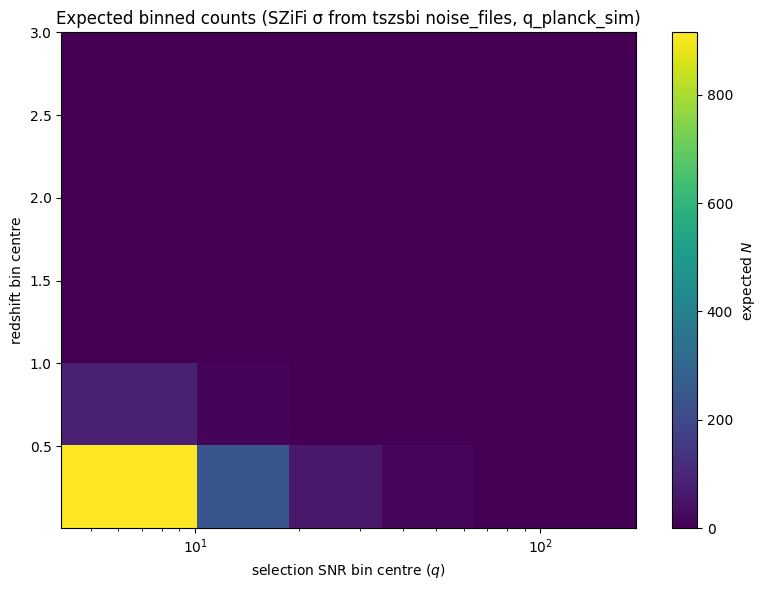

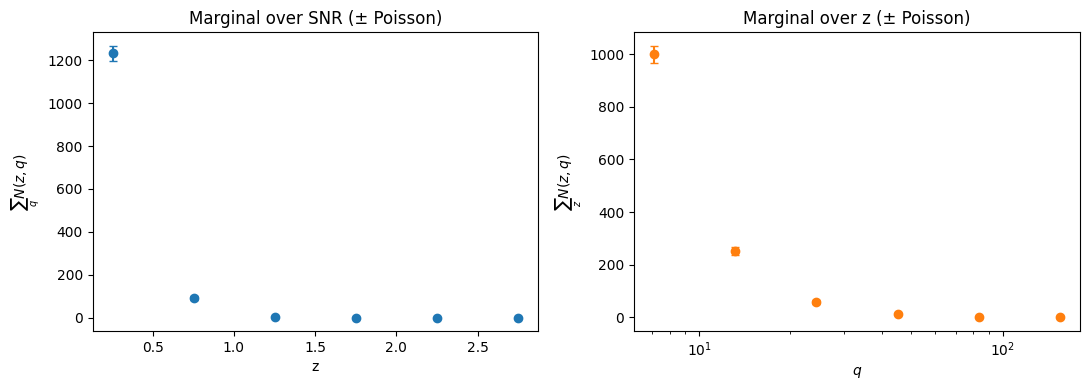

In [10]:
zc = np.asarray(nc.bins_centres_z)
qc = np.asarray(nc.bins_centres_obs)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    qc,
    zc,
    N,
    shading="auto",
    cmap="viridis",
)
ax.set_xscale("log")
ax.set_xlabel(r"selection SNR bin centre ($q$)")
ax.set_ylabel("redshift bin centre")
ax.set_title("Expected binned counts (SZiFi σ from tszsbi noise_files, q_planck_sim)")
plt.colorbar(im, ax=ax, label=r"expected $N$")
plt.tight_layout()
plt.show()

# 1D marginal over SNR: Poisson error on sum of expectations ≈ sqrt(sum N)
Nz = N.sum(axis=1)
Nq = N.sum(axis=0)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(zc, Nz, yerr=np.sqrt(np.clip(Nz, 0, None)), fmt="o", capsize=3, color="tab:blue")
ax[0].set_xlabel("z")
ax[0].set_ylabel(r"$\sum_q N(z,q)$")
ax[0].set_title("Marginal over SNR (± Poisson)")
ax[1].errorbar(qc, Nq, yerr=np.sqrt(np.clip(Nq, 0, None)), fmt="o", capsize=3, color="tab:orange")
ax[1].set_xscale("log")
ax[1].set_xlabel(r"$q$")
ax[1].set_ylabel(r"$\sum_z N(z,q)$")
ax[1].set_title("Marginal over z (± Poisson)")
plt.tight_layout()
plt.show()

### Noise paths

σ(θ) is controlled by **`tszsbi_noise_dir`** / **`tszsbi_filter_name`** on `cnc_params` (defaults: **`TSZSBI_NOISE_DIR`**, **`TSZSBI_FILTER_NAME`**). Only **`sigma_dict_szifi.npy`** and **`skyfracs_szifi_cosmology.npy`** are read — see **`tszpower.maskedpower.compute_sigma_y0`** for the same sky-average recipe.